# Time Series Analisys on Geoespatial Data with Python


Author: João Otavio Nascimento Firigato

email: joaootavionf007@gmail.com

LinkedIn: https://www.linkedin.com/in/jo%C3%A3o-otavio-firigato-4876b3aa/


## First instructions:

✅ Access the link to join our private WhatsApp community for students: https://chat.whatsapp.com/EPn27ZgR07lF3e1vnj8FiI


❗ It is important to access the Whatsapp Group to get the Colab Notebooks, as the PDF files are protected from text copying.




# Chapter 4 - Working with image time series with GEE

Let's start by importing the libraries

In [ ]:
import ee
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geemap
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

Let's authenticate and initialize the GEE library

In [ ]:
ee.Authenticate()
ee.Initialize(project='my-project-1527255156007')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


We select our analysis area and convert it to a FeatureCollection:

Link to Dataset: https://drive.google.com/drive/folders/1B2O_kfc_Ntfu2eeNVFBHdPPhH8iI_VDy?usp=sharing

In [ ]:
path_aoi_soja = '/content/drive/MyDrive/Datasets_TS/AOI_cana/cana_lotes.shp'

In [ ]:
gdf_soja = gpd.read_file(path_aoi_soja)

In [ ]:
gdf_soja

,id,geometry
0,NaN,"POLYGON ((-47.93468 -21.13461, -47.9334 -21.13..."
1,NaN,"POLYGON ((-47.93154 -21.13705, -47.92954 -21.1..."
2,NaN,"POLYGON ((-47.9231 -21.13705, -47.92215 -21.13..."
3,NaN,"POLYGON ((-47.93712 -21.13007, -47.93579 -21.1..."
4,NaN,"POLYGON ((-47.94116 -21.12812, -47.94111 -21.1..."
5,NaN,"POLYGON ((-47.92352 -21.14178, -47.92319 -21.1..."


<Axes: >

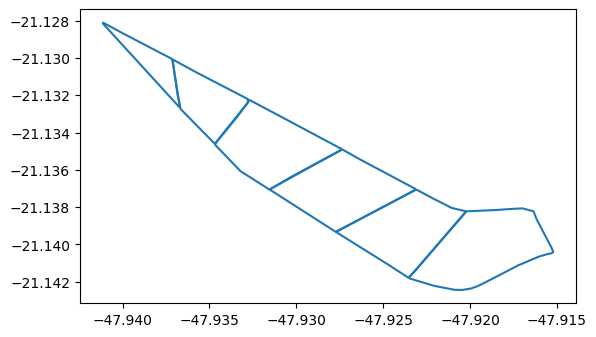

In [ ]:
gdf_soja.boundary.plot()

In [ ]:
fc = geemap.geopandas_to_ee(gdf_soja)

In [ ]:
fc

Let's get an ImageCollection of Sentinel 2 from 2017 to 2024:

In [ ]:
S2_coll = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 5)).filterDate('2017-01-01','2024-12-31').filterBounds(fc)

In [ ]:
print('Total number of images :', S2_coll.size().getInfo())

Total number of images : 162


We will create a folder to store the images:

In [ ]:
!mkdir sentinel_2_by_year

First we define a function to generate an image for each year:

In [ ]:
def create_image_collection_by_year(image_collection, fc, start_year, end_year):
  years = ee.List.sequence(start_year, end_year)

  def create_yearly_composite(year):
    start_date = ee.Date.fromYMD(year, 1, 1)
    end_date = ee.Date.fromYMD(year, 12, 31)

    year_image = image_collection \
        .filterDate(start_date, end_date) \
        .reduce(ee.Reducer.median()) \
        .set({'year': year})

    return year_image.clip(fc)

  yearly_composites = ee.ImageCollection.fromImages(
      years.map(create_yearly_composite))

  return yearly_composites


Then we apply it to our ImageCollection:

In [ ]:
start_year = 2019
end_year = 2023

yearly_s2_collection = create_image_collection_by_year(S2_coll, fc, start_year, end_year)
print('Total number of images :', yearly_s2_collection.size().getInfo())

Total number of images : 5


Let's visualize the results:

In [ ]:
Map = geemap.Map()
Map.centerObject(fc)

# Function to display an image on the map
def display_image(image):
  vis_params = {
      'bands': ['B4_median', 'B3_median', 'B2_median'],
      'min': 0,
      'max': 3000,
      'gamma': 1.4
  }
  Map.addLayer(image, vis_params, str(image.get('year').getInfo()))

# Iterate through the yearly image collection and display each image
for i in range(yearly_s2_collection.size().getInfo()):
    image = ee.Image(yearly_s2_collection.toList(yearly_s2_collection.size()).get(i))
    display_image(image)


Map

In [ ]:
start_year = 2019
end_year = 2023

This way we can export the images:

In [ ]:
geemap.ee_export_image_collection(
    yearly_s2_collection,
    out_dir="./sentinel_2_by_year",
    scale=20,
    crs='EPSG:4326',
    region=fc.geometry(),
    filenames= yearly_s2_collection.aggregate_array("year").getInfo(),
    file_per_band=False,
    timeout=300,
    proxies=None
)

Now we install rasterio to open the downloaded images and display them:

In [ ]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 53.6 MB/s eta 0:00:00


In [ ]:
import rasterio
import matplotlib.pyplot as plt
import os

image_dir = './sentinel_2_by_year'

for filename in os.listdir(image_dir):
    if filename.endswith('.tif'):
        filepath = os.path.join(image_dir, filename)

        with rasterio.open(filepath) as src:
            R = src.read(4)  # Band 4 (Red)
            G = src.read(3)  # Band 3 (Green)
            B = src.read(2)  # Band 2 (Blue)

            rgb = np.dstack((R, G, B))
            rgb = (rgb / 4000)


            plt.figure(figsize=(10, 10))
            plt.imshow(rgb)
            plt.title(filename)
            plt.axis('off')
            plt.show()


<Axes: >

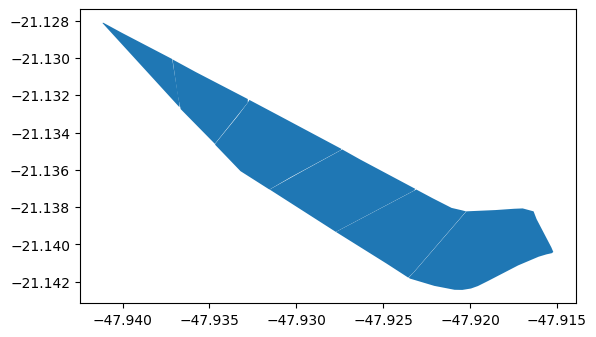

In [ ]:
gdf_soja.plot()

Let's now extract information from the polygons and images:


In [ ]:
import json
import rasterio
from rasterio.mask import mask

In [ ]:
total_gdf = gdf_soja.dissolve()

We start with NDVI information by year and for the entire area:

In [ ]:
ndvi_data = []
for year in range(start_year, end_year + 1):
  src_img = rasterio.open(f'./sentinel_2_by_year/{year}.tif')
  for feat in json.loads(total_gdf.to_json())['features']:
    out_img, _ = mask(dataset=src_img, shapes=[feat['geometry']], crop=True, nodata=-9999)

    nir = out_img[8, :, :]
    red = out_img[4, :, :]

    #Calculate NDVI, handling potential division by zero
    ndvi = np.where(red != 0, (nir - red) / (nir + red), np.nan)

    # Exclude nodata values (-9999) and NaN values when calculating mean
    valid_pixels = ndvi[ndvi != -9999]
    valid_pixels = valid_pixels[~np.isnan(valid_pixels)]
    mean_ndvi = np.nanmean(valid_pixels)

    print(f"Mean NDVI for year {year}: {mean_ndvi}")
    ndvi_data.append({'year': year, 'mean_ndvi': mean_ndvi})
ndvi_df = pd.DataFrame(ndvi_data)

Mean NDVI for year 2019: 0.11235534825508786
Mean NDVI for year 2020: 0.12091211683305336
Mean NDVI for year 2021: 0.10815726939512024


Mean NDVI for year 2022: 0.09125206936978875
Mean NDVI for year 2023: 0.10601139752554287


In [ ]:
ndvi_df

,year,mean_ndvi
0,2019,0.112355
1,2020,0.120912
2,2021,0.108157
3,2022,0.091252
4,2023,0.106011


We can also generate information by year and by polygon:

In [ ]:
ndvi_by_polygon = []
for year in range(start_year, end_year + 1):
  src_img = rasterio.open(f'./sentinel_2_by_year/{year}.tif')
  for feat in json.loads(gdf_soja.to_json())['features']:
    out_img, _ = mask(dataset=src_img, shapes=[feat['geometry']], crop=True, nodata=-9999)

    nir = out_img[8, :, :]
    red = out_img[4, :, :]

    #Calculate NDVI, handling potential division by zero
    ndvi = np.where(red != 0, (nir - red) / (nir + red), np.nan)

    # Exclude nodata values (-9999) and NaN values when calculating mean
    valid_pixels = ndvi[ndvi != -9999]
    valid_pixels = valid_pixels[~np.isnan(valid_pixels)]
    mean_ndvi = np.nanmean(valid_pixels)
    ndvi_by_polygon.append({'year': year, 'mean_ndvi': mean_ndvi, 'id_polygon': feat['id']})
ndvi_polygon_df = pd.DataFrame(ndvi_by_polygon)

In [ ]:
ndvi_polygon_df

,year,mean_ndvi,id_polygon
0,2019,0.211833,0
1,2019,0.222753,1
2,2019,0.215872,2
3,2019,0.243543,3
4,2019,0.102792,4
5,2019,0.271991,5
6,2020,0.243169,0
7,2020,0.253338,1
8,2020,0.248999,2
9,2020,0.227691,3


And finally we will create some spectral indices and obtain the information by year and by plot:

In [ ]:
ndvi_ndre_ndwi_by_polygon = []
for year in range(start_year, end_year + 1):
  src_img = rasterio.open(f'./sentinel_2_by_year/{year}.tif')
  for feat in json.loads(gdf_soja.to_json())['features']:
    out_img, _ = mask(dataset=src_img, shapes=[feat['geometry']], crop=True, nodata=-9999)

    nir = out_img[8, :, :]
    red = out_img[4, :, :]
    re = out_img[5, :, :]
    green = out_img[3, :, :]

    #Calculate NDVI
    ndvi = np.where(red != 0, (nir - red) / (nir + red), np.nan)
    #Calculate NDRE
    ndre = np.where(nir != 0, (nir - re) / (nir + re), np.nan)
    #Calculate NDWI
    ndwi = np.where((green + nir) != 0, (green - nir) / (green + nir), np.nan)

    # Exclude nodata values (-9999) and NaN values when calculating mean
    valid_pixels_ndvi = ndvi[ndvi != -9999]
    valid_pixels_ndvi = valid_pixels_ndvi[~np.isnan(valid_pixels_ndvi)]
    mean_ndvi = np.nanmean(valid_pixels_ndvi)

    valid_pixels_ndre = ndre[ndre != -9999]
    valid_pixels_ndre = valid_pixels_ndre[~np.isnan(valid_pixels_ndre)]
    mean_ndre = np.nanmean(valid_pixels_ndre)

    valid_pixels_ndwi = ndwi[ndwi != -9999]
    valid_pixels_ndwi = valid_pixels_ndwi[~np.isnan(valid_pixels_ndwi)]
    mean_ndwi = np.nanmean(valid_pixels_ndwi)


    ndvi_ndre_ndwi_by_polygon.append({'year': year, 'mean_ndvi': mean_ndvi, 'mean_ndre':mean_ndre, 'mean_ndwi': mean_ndwi, 'id_polygon': feat['id']})
ndvi_ndre_ndwi_polygon_df = pd.DataFrame(ndvi_ndre_ndwi_by_polygon)

In [ ]:
ndvi_ndre_ndwi_polygon_df

,year,mean_ndvi,mean_ndre,mean_ndwi,id_polygon
0,2019,0.211833,0.071175,-0.292873,0
1,2019,0.222753,0.074579,-0.308874,1
2,2019,0.215872,0.071267,-0.296813,2
3,2019,0.243543,0.058453,-0.335602,3
4,2019,0.102792,0.024878,-0.147474,4
5,2019,0.271991,0.078054,-0.351619,5
6,2020,0.243169,0.056209,-0.339234,0
7,2020,0.253338,0.059032,-0.354262,1
8,2020,0.248999,0.060208,-0.341119,2
9,2020,0.227691,0.058162,-0.314856,3


# Timelapses

One feature of the geemap library is the creation of timelapses. Let's create some:

In [ ]:
Map = geemap.Map()

In [ ]:
roi = Map.user_roi
if roi is None:
    roi = ee.Geometry.BBox(-18.6983, -36.1630, 52.2293, 38.1446)
    Map.addLayer(roi)
    Map.centerObject(roi)

First one using NDVI from the MODIS satellite


In [ ]:
timelapse = geemap.modis_ndvi_timelapse(
    roi,
    out_gif='ndvi.gif',
    data='Terra',
    band='NDVI',
    start_date='2000-01-01',
    end_date='2022-12-31',
    frames_per_second=3,
    title='MODIS NDVI Timelapse',
    overlay_data='countries',
)
geemap.show_image(timelapse)

In [ ]:
roi = ee.Geometry.BBox(-171.21, -57.13, 177.53, 79.99)
Map.addLayer(roi)
Map.centerObject(roi)

Then the temperature of the oceans:


In [ ]:
timelapse = geemap.modis_ocean_color_timelapse(
    satellite='Aqua',
    start_date='2018-01-01',
    end_date='2020-12-31',
    roi=roi,
    frequency='month',
    out_gif='temperature.gif',
    overlay_data='continents',
    overlay_color='yellow',
    overlay_opacity=0.5,
)
geemap.show_image(timelapse)

In [ ]:
from IPython.display import Image

Image(filename='temperature.gif')


## Thank you! See you in the next Chapter!